In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import pytimetk as tk
import numpy as np
import pytensor as pt
import arviz as az
import seaborn as sns
import pymc as pm

In [46]:
df = pd.read_csv("mmm_spend_data.csv", parse_dates=['start_of_week']);
df = df.sort_values("start_of_week").reset_index(drop=True)

In [47]:
df.describe()
channels=['spend_channel_1',
 'spend_channel_2',
 'spend_channel_3',
 'spend_channel_4',
 'spend_channel_5',
 'spend_channel_6',
 'spend_channel_7']

In [48]:
df.columns.tolist()

['start_of_week',
 'revenue',
 'spend_channel_1',
 'spend_channel_2',
 'spend_channel_3',
 'spend_channel_4',
 'spend_channel_5',
 'spend_channel_6',
 'spend_channel_7']

<Axes: xlabel='revenue', ylabel='Count'>

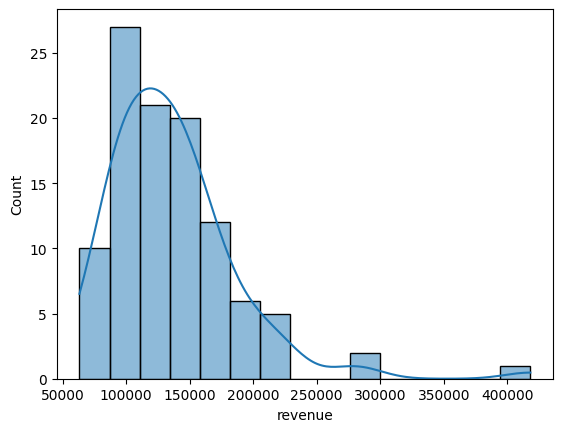

In [49]:
sns.histplot(df['revenue'], kde=True)

<Axes: >

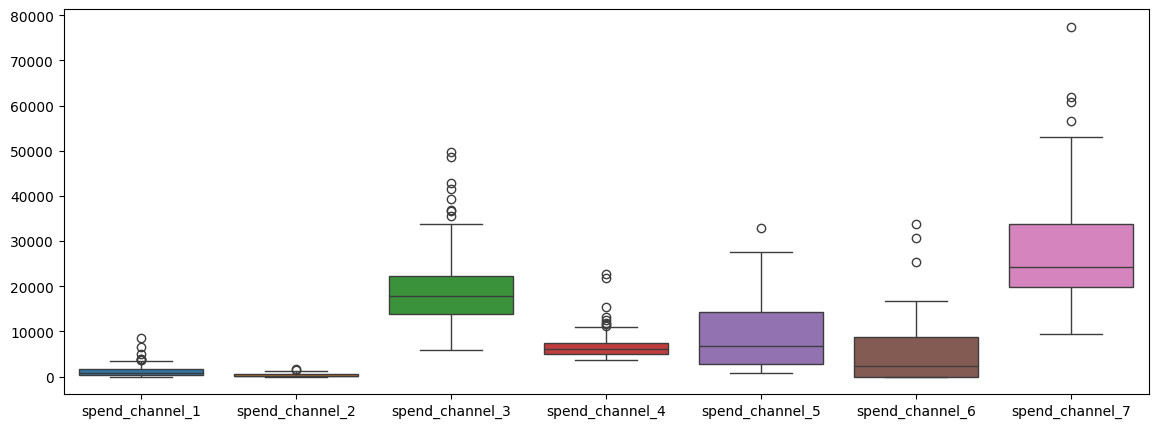

In [50]:
plt.figure(figsize=(14, 5))

sns.boxplot(data=df[channels])

In [51]:
(df[channels] == 0).sum()

spend_channel_1    13
spend_channel_2     0
spend_channel_3     0
spend_channel_4     0
spend_channel_5     0
spend_channel_6    39
spend_channel_7     0
dtype: int64

In [52]:
df[channels].sum()

spend_channel_1     129542.90
spend_channel_2      35738.66
spend_channel_3    2028746.51
spend_channel_4     719174.22
spend_channel_5     891863.59
spend_channel_6     526624.70
spend_channel_7    2880942.21
dtype: float64

In [53]:
revenue = df["revenue"]
spend = df[channels]
revenue_scaled = revenue / revenue.max()
spend_scaled = spend / spend.max(axis=0)
df_scaled = pd.concat([df["start_of_week"], revenue_scaled, spend_scaled], axis=1)
df_scaled

,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
0,2020-01-11,0.509622,0.043481,0.061606,0.493249,0.220167,0.271011,0.232616,0.229309
1,2020-04-10,0.467689,0.429324,0.326967,0.362743,0.430385,0.630241,0.755224,0.392245
2,2020-06-09,0.445796,0.309380,0.067665,0.176301,0.201532,0.386181,0.366196,0.290023
3,2020-06-12,0.359704,0.161242,0.087991,0.204952,0.319334,0.448606,0.445114,0.267721
4,2020-08-11,0.483806,0.202453,0.084846,0.715455,0.214211,0.444812,0.362493,0.324276
...,...,...,...,...,...,...,...,...,...
99,2022-08-21,0.201811,0.000000,0.241579,0.216498,0.207401,0.090038,0.000000,0.394216
100,2022-09-01,0.423201,0.121351,0.072385,0.420323,0.289761,0.050725,0.000000,0.594663
101,2022-10-04,0.392710,0.050365,1.000000,1.000000,0.525524,0.116380,0.096733,1.000000
102,2022-10-07,0.172704,0.000000,0.200934,0.346111,0.253532,0.098286,0.000000,0.389211


In [54]:
df_scaled.melt(id_vars=['start_of_week'], value_vars=['revenue',
 'spend_channel_1',
 'spend_channel_2',
 'spend_channel_3',
 'spend_channel_4',
 'spend_channel_5',
 'spend_channel_6',
 'spend_channel_7']).groupby("variable").plot_timeseries("start_of_week", "value", color_column="variable", facet_ncol=2, width=1200, height=1000, legend_show=False)

In [55]:
imp_cols = ['revenue',
 'spend_channel_1',
 'spend_channel_2',
 'spend_channel_3',
 'spend_channel_4',
 'spend_channel_5',
 'spend_channel_6',
 'spend_channel_7']
corr = df_scaled[imp_cols].corr()
corr

,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
revenue,1.000000,0.323828,0.080848,0.381686,0.255698,0.421304,0.522644,0.249895
spend_channel_1,0.323828,1.000000,-0.107805,0.310750,0.306163,0.556469,0.514291,0.102148
spend_channel_2,0.080848,-0.107805,1.000000,0.276014,0.396803,-0.306958,-0.077497,0.588705
spend_channel_3,0.381686,0.310750,0.276014,1.000000,0.504139,0.037029,0.170534,0.496535
spend_channel_4,0.255698,0.306163,0.396803,0.504139,1.000000,-0.182030,0.013237,0.559980
spend_channel_5,0.421304,0.556469,-0.306958,0.037029,-0.182030,1.000000,0.650802,-0.274113
spend_channel_6,0.522644,0.514291,-0.077497,0.170534,0.013237,0.650802,1.000000,0.024605
spend_channel_7,0.249895,0.102148,0.588705,0.496535,0.559980,-0.274113,0.024605,1.000000


<Axes: >

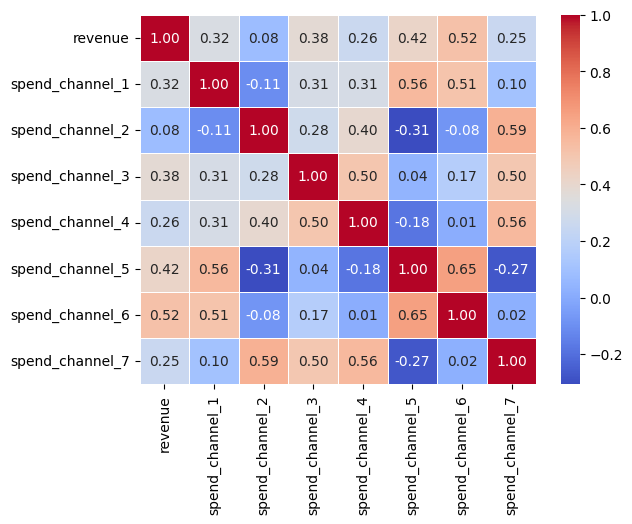

In [56]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

In [57]:
df[channels].mean()

spend_channel_1     1245.604808
spend_channel_2      343.640962
spend_channel_3    19507.177981
spend_channel_4     6915.136731
spend_channel_5     8575.611442
spend_channel_6     5063.699038
spend_channel_7    27701.367404
dtype: float64

In [58]:
np.linspace(0, 1, len(df))

array([0.        , 0.00970874, 0.01941748, 0.02912621, 0.03883495,
       0.04854369, 0.05825243, 0.06796117, 0.0776699 , 0.08737864,
       0.09708738, 0.10679612, 0.11650485, 0.12621359, 0.13592233,
       0.14563107, 0.15533981, 0.16504854, 0.17475728, 0.18446602,
       0.19417476, 0.2038835 , 0.21359223, 0.22330097, 0.23300971,
       0.24271845, 0.25242718, 0.26213592, 0.27184466, 0.2815534 ,
       0.29126214, 0.30097087, 0.31067961, 0.32038835, 0.33009709,
       0.33980583, 0.34951456, 0.3592233 , 0.36893204, 0.37864078,
       0.38834951, 0.39805825, 0.40776699, 0.41747573, 0.42718447,
       0.4368932 , 0.44660194, 0.45631068, 0.46601942, 0.47572816,
       0.48543689, 0.49514563, 0.50485437, 0.51456311, 0.52427184,
       0.53398058, 0.54368932, 0.55339806, 0.5631068 , 0.57281553,
       0.58252427, 0.59223301, 0.60194175, 0.61165049, 0.62135922,
       0.63106796, 0.6407767 , 0.65048544, 0.66019417, 0.66990291,
       0.67961165, 0.68932039, 0.69902913, 0.70873786, 0.71844

In [59]:
df_features = df_scaled.assign(trend = lambda x: np.linspace(0, 1, len(x)))
df_features

,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7,trend
0,2020-01-11,0.509622,0.043481,0.061606,0.493249,0.220167,0.271011,0.232616,0.229309,0.000000
1,2020-04-10,0.467689,0.429324,0.326967,0.362743,0.430385,0.630241,0.755224,0.392245,0.009709
2,2020-06-09,0.445796,0.309380,0.067665,0.176301,0.201532,0.386181,0.366196,0.290023,0.019417
3,2020-06-12,0.359704,0.161242,0.087991,0.204952,0.319334,0.448606,0.445114,0.267721,0.029126
4,2020-08-11,0.483806,0.202453,0.084846,0.715455,0.214211,0.444812,0.362493,0.324276,0.038835
...,...,...,...,...,...,...,...,...,...,...
99,2022-08-21,0.201811,0.000000,0.241579,0.216498,0.207401,0.090038,0.000000,0.394216,0.961165
100,2022-09-01,0.423201,0.121351,0.072385,0.420323,0.289761,0.050725,0.000000,0.594663,0.970874
101,2022-10-04,0.392710,0.050365,1.000000,1.000000,0.525524,0.116380,0.096733,1.000000,0.980583
102,2022-10-07,0.172704,0.000000,0.200934,0.346111,0.253532,0.098286,0.000000,0.389211,0.990291


In [60]:
K = 2
t_idx = np.arange(len(df))
for k in range(1, K+1):
    df_features[f"sin_{k}"] = np.sin(2 * np.pi * k * t_idx / 52)
    df_features[f"cos_{k}"] = np.cos(2 * np.pi * k * t_idx / 52)

df_features


,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7,trend,sin_1,cos_1,sin_2,cos_2
0,2020-01-11,0.509622,0.043481,0.061606,0.493249,0.220167,0.271011,0.232616,0.229309,0.000000,0.000000,1.000000,0.000000,1.000000
1,2020-04-10,0.467689,0.429324,0.326967,0.362743,0.430385,0.630241,0.755224,0.392245,0.009709,0.120537,0.992709,0.239316,0.970942
2,2020-06-09,0.445796,0.309380,0.067665,0.176301,0.201532,0.386181,0.366196,0.290023,0.019417,0.239316,0.970942,0.464723,0.885456
3,2020-06-12,0.359704,0.161242,0.087991,0.204952,0.319334,0.448606,0.445114,0.267721,0.029126,0.354605,0.935016,0.663123,0.748511
4,2020-08-11,0.483806,0.202453,0.084846,0.715455,0.214211,0.444812,0.362493,0.324276,0.038835,0.464723,0.885456,0.822984,0.568065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,2022-08-21,0.201811,0.000000,0.241579,0.216498,0.207401,0.090038,0.000000,0.394216,0.961165,-0.568065,0.822984,-0.935016,0.354605
100,2022-09-01,0.423201,0.121351,0.072385,0.420323,0.289761,0.050725,0.000000,0.594663,0.970874,-0.464723,0.885456,-0.822984,0.568065
101,2022-10-04,0.392710,0.050365,1.000000,1.000000,0.525524,0.116380,0.096733,1.000000,0.980583,-0.354605,0.935016,-0.663123,0.748511
102,2022-10-07,0.172704,0.000000,0.200934,0.346111,0.253532,0.098286,0.000000,0.389211,0.990291,-0.239316,0.970942,-0.464723,0.885456


In [61]:
# total_spend_per_channel = df[channels].sum()
# spend_proportion = total_spend_per_channel / total_spend_per_channel.sum()
# spend_proportion

In [62]:
n_channels = len(channels)
# HALFNORMAL_SCALE = 1 / np.sqrt(1 - 2 / np.pi)
# prior_sigma_channels = HALFNORMAL_SCALE * spend_proportion
# prior_sigma_channels

In [63]:
def adstock_step(spend_t, adstock_prev, alpha):
    return spend_t + alpha * adstock_prev
def adstock(spend_vector, alpha):
    adstocked, _ = pt.scan(
        fn=adstock_step,
        sequences=[spend_vector],
        outputs_info=[pt.tensor.cast(pt.tensor.constant(0.0), spend_vector.dtype)],
        non_sequences=[alpha]
    )
    return adstocked

In [64]:
spend_array = spend_scaled[channels].values.astype("float64")
fourier_matrix = df_features[["sin_1","cos_1","sin_2","cos_2"]].values.astype("float64")
t_trend = df_features["trend"].values.astype("float64")

with pm.Model() as mmm_model:
    spend_data   = pm.Data("spend_data",spend_array)
    fourier_data = pm.Data("fourier_data",fourier_matrix)
    trend_data   = pm.Data("trend_data", t_trend)

    intercept = pm.Normal("intercept", mu=0.3, sigma=0.1)
    # beta_channel = pm.HalfNormal("beta_channel", sigma=prior_sigma_channels.values, shape=n_channels)
    beta_channel = pm.HalfNormal("beta_channel", sigma=0.14, shape=n_channels)
    alpha = pm.Beta("alpha", alpha=2, beta=2, shape=n_channels)
    beta_trend = pm.Normal("beta_trend", mu=0, sigma=0.15)
    gamma_fourier = pm.Laplace("gamma_fourier", mu=0, b=0.2, shape=K * 2)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.1)
    adstocked_channels = pt.tensor.stack(
        [adstock(spend_data[:, c], alpha[c]) for c in range(n_channels)],
        axis=1
    )
    total_channel_effect = pt.tensor.sum(adstocked_channels * beta_channel, axis=1)
    trend_contribution   = beta_trend * trend_data
    seasonality_contrib  = pm.math.dot(fourier_data, gamma_fourier)
    mu = intercept + total_channel_effect + trend_contribution + seasonality_contrib
    mu = pm.Deterministic("mu", mu)
    channel_contributions = pm.Deterministic(
      "channel_contributions", adstocked_channels * beta_channel
    )
    trend_contrib = pm.Deterministic("trend_contrib", trend_contribution)
    season_contrib = pm.Deterministic("season_contrib", seasonality_contrib)
    intercept_contrib = pm.Deterministic(
        "intercept_contrib", pt.tensor.full_like(trend_data, intercept)
    )

    pm.Normal("revenue_obs", mu=mu, sigma=sigma_obs, observed=revenue_scaled.values)
    # idata = pm.sample(1000, tune=1000, target_accept=0.95)

In [65]:
with mmm_model:
    prior_checks = pm.sample_prior_predictive(samples=500, random_seed=42)

prior_rev = prior_checks.prior_predictive["revenue_obs"].values * revenue.max()
print(f"5th  pct: €{np.percentile(prior_rev, 5):,.0f}")
print(f"10th pct: €{np.percentile(prior_rev, 10):,.0f}")
print(f"50th pct: €{np.percentile(prior_rev, 50):,.0f}")
print(f"90th pct: €{np.percentile(prior_rev, 90):,.0f}")
print(f"95th pct: €{np.percentile(prior_rev, 95):,.0f}")

Sampling: [alpha, beta_channel, beta_trend, gamma_fourier, intercept, revenue_obs, sigma_obs]


5th  pct: €2,129
10th pct: €84,038
50th pct: €346,859
90th pct: €656,470
95th pct: €779,955


In [66]:
with mmm_model:
  prior_checks = pm.sample_prior_predictive(samples=500, random_seed=42)
  idata = pm.sample(1000, tune=1000, target_accept=0.95, random_seed=42, nuts_sampler="nutpie")
  pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=42)


Sampling: [alpha, beta_channel, beta_trend, gamma_fourier, intercept, revenue_obs, sigma_obs]


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.13,31
,2000,0,0.13,95
,2000,1,0.14,31
,2000,0,0.13,31


Sampling: [revenue_obs]


Output()

In [67]:
mu_mean = idata.posterior["mu"].mean(dim=["chain", "draw"]).values

# rescale back to original
revenue_pred = mu_mean * df["revenue"].max()
revenue_actual = df["revenue"].values

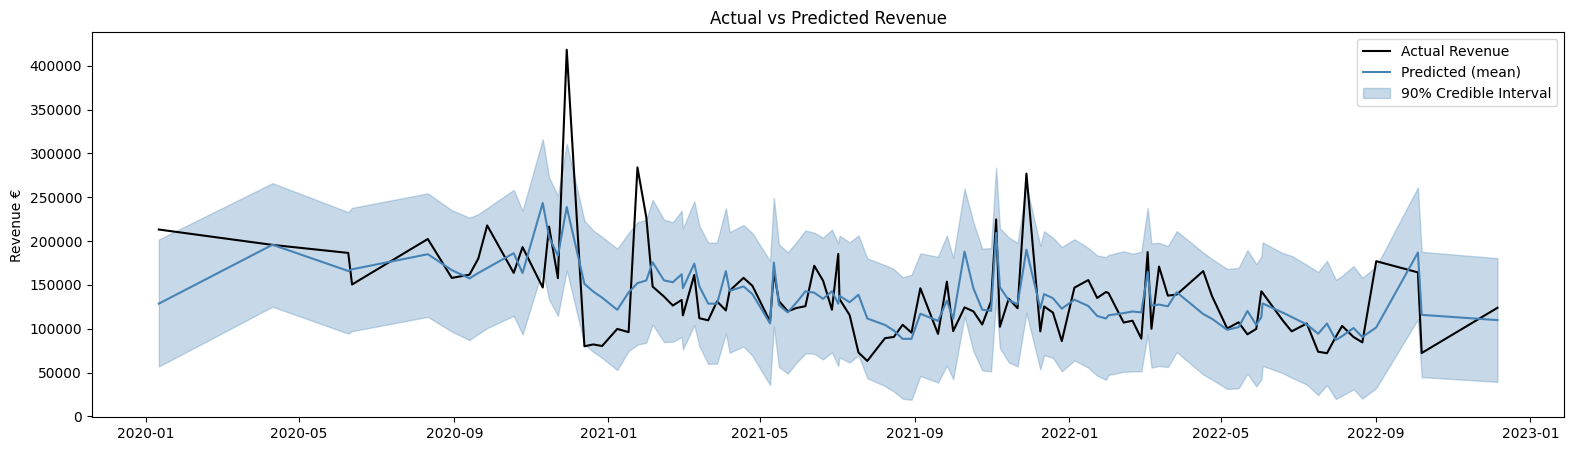

In [68]:
pred_revenue = idata.posterior_predictive["revenue_obs"]
pred_mean    = pred_revenue.mean(dim=["chain", "draw"]).values * revenue.max()
pred_lower   = pred_revenue.quantile(0.05, dim=["chain", "draw"]).values * revenue.max()
pred_upper   = pred_revenue.quantile(0.95, dim=["chain", "draw"]).values * revenue.max()

fig, ax = plt.subplots(figsize=(19, 5))
ax.plot(df["start_of_week"], revenue, label="Actual Revenue", color="black")
ax.plot(df["start_of_week"], pred_mean, label="Predicted (mean)", color="steelblue")
ax.fill_between(df["start_of_week"], pred_lower, pred_upper, alpha=0.3, color="steelblue", label="90% Credible Interval")
ax.set_title("Actual vs Predicted Revenue")
ax.set_ylabel("Revenue €")
ax.legend()
plt.show()

In [69]:
summary = az.summary(idata, var_names=["intercept", "beta_channel", "alpha",
                                        "beta_trend", "gamma_fourier", "sigma_obs"])
rhat_values = summary["r_hat"]
print(f"max r-hat: {rhat_values.max()}")
print(f"min ess: {summary['ess_bulk'].min()}")
summary

max r-hat: 1.0
min ess: 1059.0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,0.172,0.044,0.093,0.263,0.001,0.001,1514.0,1712.0,1.0
beta_channel[0],0.023,0.022,0.000,0.065,0.000,0.000,2514.0,1623.0,1.0
beta_channel[1],0.078,0.047,0.000,0.156,0.001,0.001,1464.0,1294.0,1.0
beta_channel[2],0.095,0.056,0.000,0.190,0.001,0.001,1137.0,558.0,1.0
beta_channel[3],0.064,0.050,0.000,0.155,0.001,0.001,1362.0,1181.0,1.0
beta_channel[4],0.067,0.045,0.000,0.147,0.001,0.001,1404.0,1226.0,1.0
beta_channel[5],0.106,0.055,0.001,0.196,0.001,0.001,1873.0,1460.0,1.0
beta_channel[6],0.110,0.065,0.000,0.219,0.002,0.001,1059.0,735.0,1.0
alpha[0],0.421,0.211,0.052,0.794,0.003,0.003,5885.0,2927.0,1.0
alpha[1],0.413,0.205,0.060,0.780,0.004,0.002,2884.0,2530.0,1.0


In [70]:
channel_contrib = idata.posterior["channel_contributions"]
total_spend = df[channels].sum().values
roas = (channel_contrib.sum(dim="channel_contributions_dim_0") * df["revenue"].max() / total_spend)
roas_flat = roas.stack(samples=("chain", "draw")).values.T

roas_df = (
    roas
    .to_dataframe(name="roas")
    .reset_index()
    .rename(columns={"channel_contributions_dim_1": "channel"})
)
roas_df["channel"] = roas_df["channel"].map(lambda i: channels[i])
roas_mean = roas_df.groupby("channel").mean()
roas_describe = roas_df.groupby("channel")["roas"].describe(percentiles=[0.025, 0.975])
roas_describe

,count,mean,std,min,2.5%,50%,97.5%,max
channel,,,,,,,,
spend_channel_1,4000.0,2.058474,1.993962,0.000842,0.049347,1.498788,7.019656,16.092101
spend_channel_2,4000.0,36.003501,21.515557,0.069900,3.276503,33.849164,85.501319,152.278913
spend_channel_3,4000.0,1.064399,0.574436,0.000208,0.076241,1.029745,2.252755,3.422996
spend_channel_4,4000.0,1.810124,1.307728,0.000787,0.072626,1.572409,4.857082,8.308217
spend_channel_5,4000.0,1.272327,0.788011,0.001538,0.090012,1.177432,2.994298,4.933121
spend_channel_6,4000.0,2.040799,1.036673,0.003531,0.259385,1.959385,4.196094,6.878619
spend_channel_7,4000.0,0.825391,0.450087,0.000396,0.066586,0.812288,1.769345,3.395052


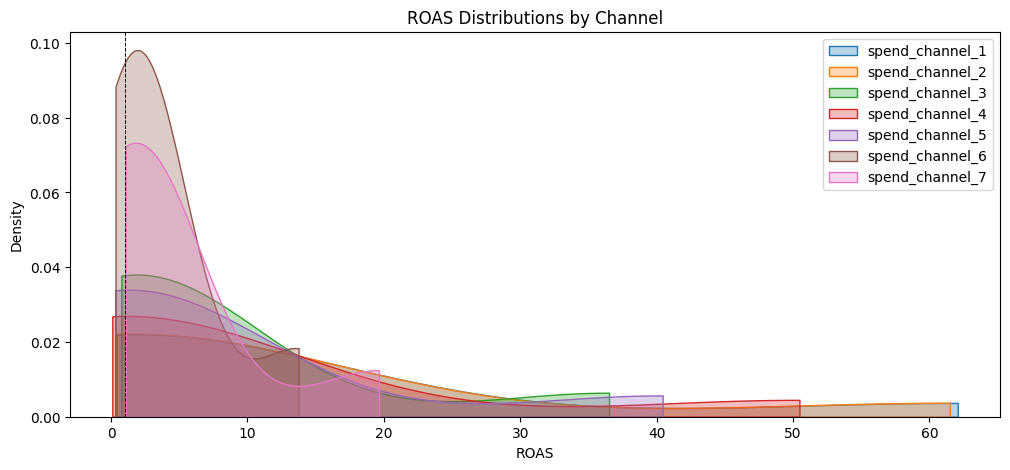

In [71]:

plt.figure(figsize=(12, 5))
for c in range(n_channels):
    sns.kdeplot(roas_flat[c], label=channels[c], fill=True, alpha=0.3, cut=0)
plt.axvline(1.0, color="k", ls="--", lw=0.7)  # breakeven
plt.xlabel("ROAS")
plt.ylabel("Density")
plt.title("ROAS Distributions by Channel")
plt.legend()
plt.show()

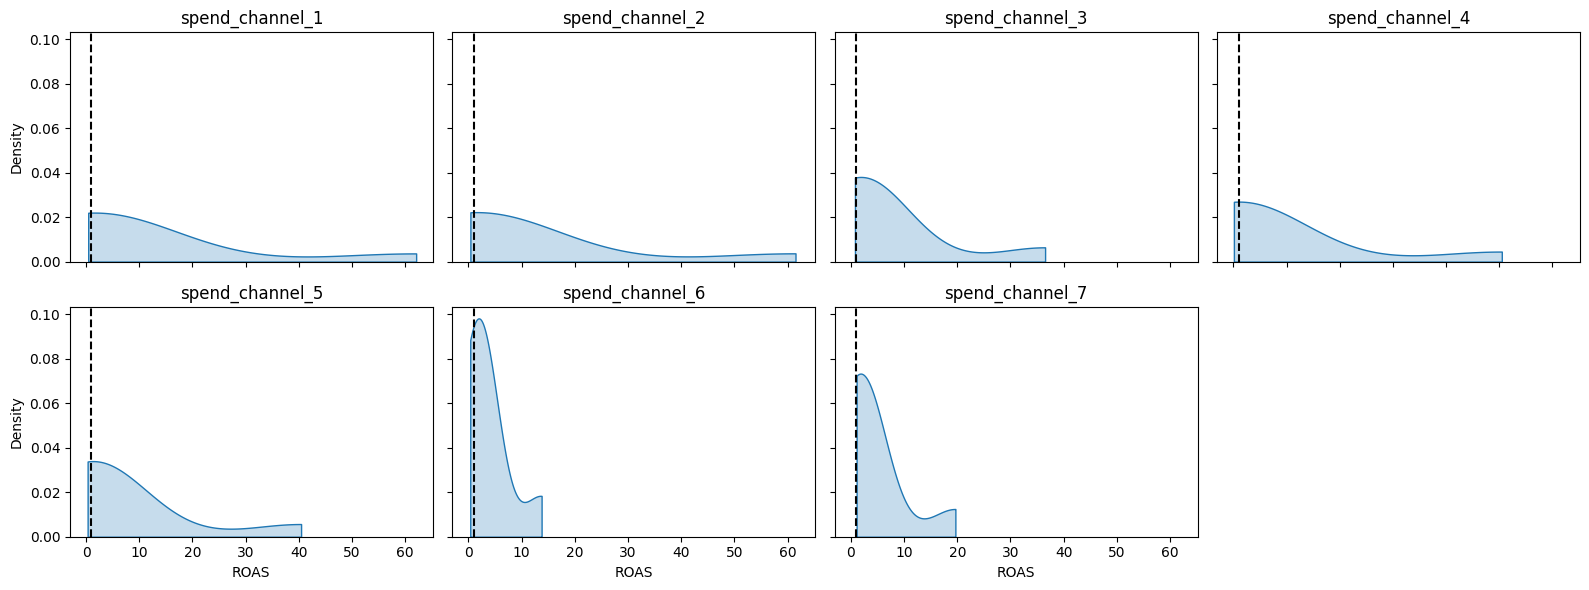

In [72]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)
axes = axes.flatten()
for c in range(n_channels):
    sns.kdeplot(roas_flat[c], fill=True, ax=axes[c], cut=0)
    axes[c].axvline(1.0, color="k", ls="--")
    axes[c].set_title(channels[c])
    axes[c].set_xlabel("ROAS")
axes[-1].remove()
plt.tight_layout()
plt.show()

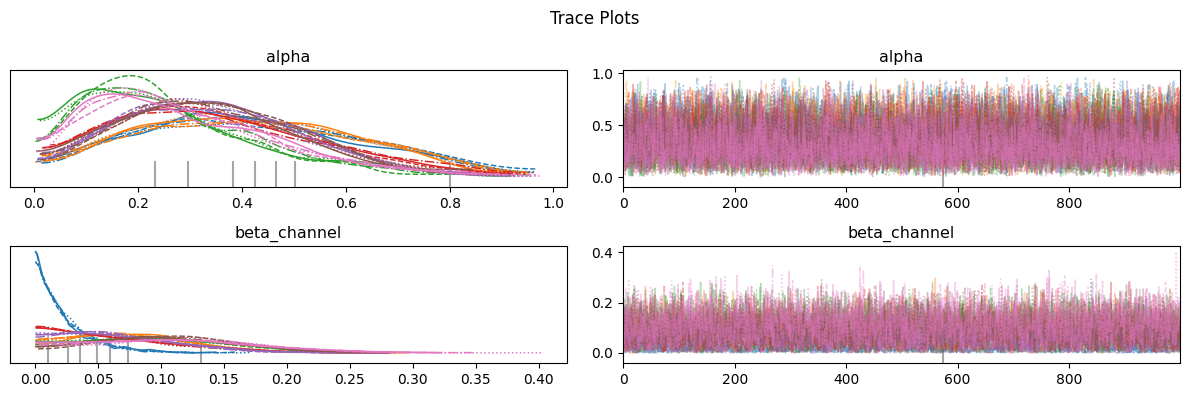

In [73]:
az.plot_trace(idata, var_names=["alpha", "beta_channel"])
plt.suptitle("Trace Plots")
plt.tight_layout()
plt.show()

In [74]:
mape = np.mean(np.abs((revenue - pred_mean) / revenue)) * 100
rmse = np.sqrt(np.mean((revenue - pred_mean) ** 2))
ss_res = np.sum((revenue - pred_mean) ** 2)
ss_tot = np.sum((revenue - revenue.mean()) ** 2)
r2     = 1 - ss_res / ss_tot

print(f"R^2 = {r2}")
print(f"MAPE = {mape}%")
print(f"RMSE = €{rmse}")


R^2 = 0.42007592953438844
MAPE = 20.555871965792665%
RMSE = €38506.927540089


In [75]:
beta_posterior = idata.posterior["beta_channel"].values
beta_flat      = beta_posterior.reshape(-1, n_channels)
hdi_results = np.array([az.hdi(beta_flat[:, i], hdi_prob=0.94) for i in range(n_channels)])
beta_df = pd.DataFrame({
    "channel": channels,
    "mean": beta_flat.mean(axis=0),
    "hdi_3_percentage": hdi_results[:, 0],
    "hdi_97_percentage": hdi_results[:, 1],
    "p(>0)": (beta_flat > 0).mean(axis=0)
})
beta_df

,channel,mean,hdi_3_percentage,hdi_97_percentage,p(>0)
0,spend_channel_1,0.022749,0.000011,0.064922,1.0
1,spend_channel_2,0.077556,0.000142,0.156070,1.0
2,spend_channel_3,0.095492,0.000017,0.189516,1.0
3,spend_channel_4,0.064169,0.000028,0.154554,1.0
4,spend_channel_5,0.066696,0.000072,0.146812,1.0
5,spend_channel_6,0.105970,0.001035,0.195658,1.0
6,spend_channel_7,0.110427,0.000047,0.218901,1.0


In [79]:
beta_means = idata.posterior["beta_channel"].mean(dim=["chain", "draw"]).values
alpha_means = idata.posterior["alpha"].mean(dim=["chain", "draw"]).values
adstocked = np.zeros_like(spend_scaled[channels].values)

for i in range(n_channels):
    s = spend_scaled[channels].values[:, i]
    a = alpha_means[i]
    for t in range(len(s)):
        adstocked[t, i] = s[t] + a * (adstocked[t-1, i] if t > 0 else 0)

roi_df = pd.DataFrame({
    "channel": channels,
    "beta_mean": beta_means,
    "total_spend": spend[channels].sum().values,
    "attr_revenue":beta_means * adstocked.sum(axis=0) * revenue.max(),
})
roi_df["roi"] = roi_df["attr_revenue"] / roi_df["total_spend"]
roi_df

,channel,beta_mean,total_spend,attr_revenue,roi
0,spend_channel_1,0.022749,129542.90,2.497204e+05,1.927704
1,spend_channel_2,0.077556,35738.66,1.209618e+06,33.846207
2,spend_channel_3,0.095492,2028746.51,2.204297e+06,1.086532
3,spend_channel_4,0.064169,719174.22,1.313902e+06,1.826959
4,spend_channel_5,0.066696,891863.59,1.143440e+06,1.282079
5,spend_channel_6,0.105970,526624.70,1.049331e+06,1.992559
6,spend_channel_7,0.110427,2880942.21,2.401512e+06,0.833586


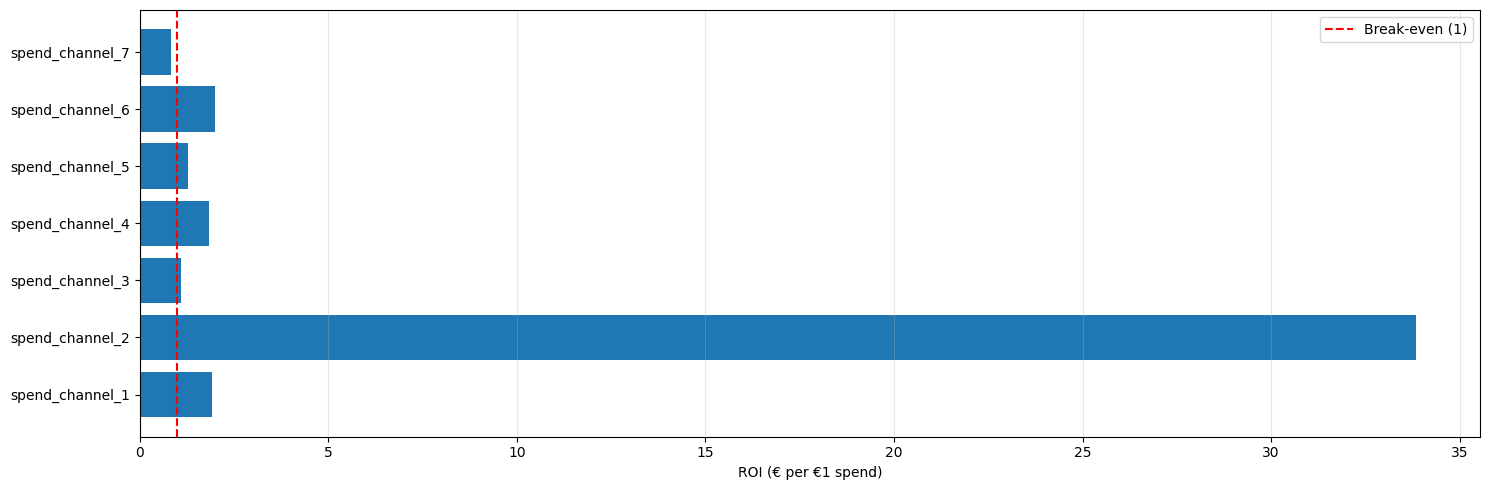

In [80]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.barh(roi_df["channel"], roi_df["roi"])
ax.axvline(1, color="red", ls="--", label="Break-even (1)")
ax.set_xlabel("ROI (€ per €1 spend)")
ax.legend()
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

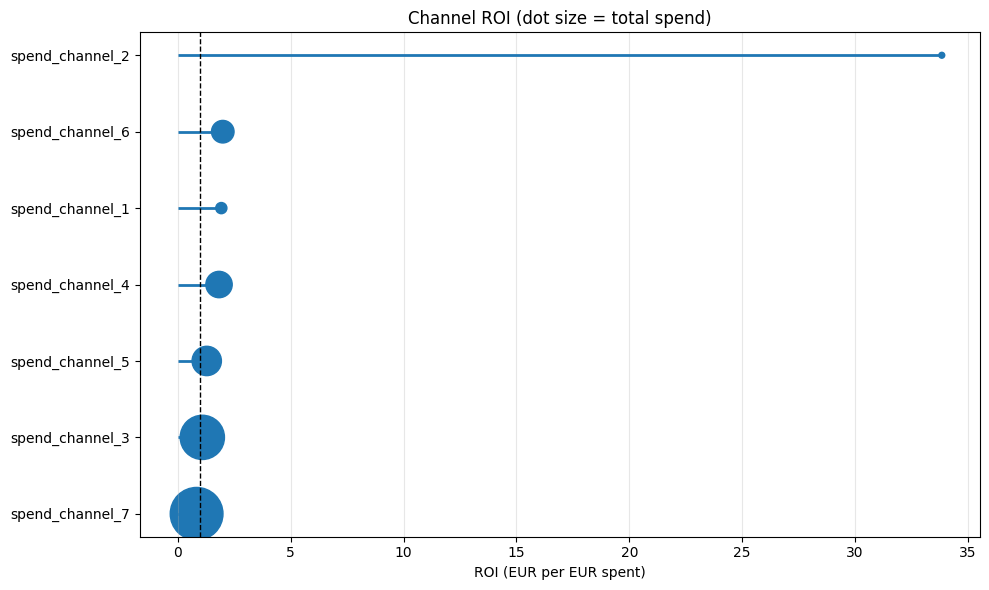

In [78]:
roi_plot_df = roi_df.sort_values("roi", ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(roi_plot_df))
ax.hlines(y=y_pos, xmin=0, xmax=roi_plot_df["roi"], linewidth=2)
ax.scatter(roi_plot_df["roi"], y_pos, s=roi_plot_df["total_spend"] / 2000)
ax.set_yticks(y_pos)
ax.set_yticklabels(roi_plot_df["channel"])
ax.axvline(x=1, color="black", linestyle="--", linewidth=1, label="Break-even (ROI = 1)")
ax.set_xlabel("ROI (EUR per EUR spent)")
ax.set_title("Channel ROI (dot size = total spend)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()